# Welcome to Colab!

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving LungCanC2024_Dataset.csv to LungCanC2024_Dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("LungCanC2024_Dataset.csv")

print("Dataset loaded successfully ✅")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully ✅
Shape: (289010, 27)


,nodule_size_mm,nodule_texture,HU_mean,HU_std,GLCM_contrast,GLCM_correlation,PET_SUVmax,PET_SUVmean,patient_age,patient_gender,...,targeted_therapy_received,EGFR_mutation_status,KRAS_mutation_status,ALK_fusion_status,PD-L1_expression_level,tumor_mutational_burden,cancer_presence,cancer_subtype,cancer_stage,survival_time_months
0,3.754145,0.779723,-719.889488,160.069061,11.093420,0.877811,0.964536,1.896542,85,Male,...,0,0,1,0,42.178630,0.413221,1,No Cancer,Stage II,23.916617
1,24.080971,0.873834,-259.176808,122.088962,2.739776,0.610637,12.441004,0.501087,81,Male,...,0,1,1,0,97.468371,0.763461,1,Squamous Cell,Stage III,11.859306
2,10.533966,0.728628,-757.122831,135.105965,0.115492,0.524141,9.711270,0.356903,64,Male,...,0,1,0,1,95.115583,4.357365,0,Adenocarcinoma,Stage I,14.177438
3,7.303540,0.826359,-249.694708,242.576964,2.941016,0.507490,2.817405,2.744690,85,Male,...,0,0,0,1,28.871351,1.288862,1,No Cancer,No Cancer,37.703014
4,1.356999,0.490455,-697.653568,44.987641,4.093630,0.543351,0.396519,2.753422,38,Male,...,0,0,0,0,64.792249,6.477791,1,Squamous Cell,No Cancer,2.828828


✅ Dataset Loaded
Shape: (289010, 27)


,nodule_size_mm,nodule_texture,HU_mean,HU_std,GLCM_contrast,GLCM_correlation,PET_SUVmax,PET_SUVmean,patient_age,patient_gender,...,targeted_therapy_received,EGFR_mutation_status,KRAS_mutation_status,ALK_fusion_status,PD-L1_expression_level,tumor_mutational_burden,cancer_presence,cancer_subtype,cancer_stage,survival_time_months
0,3.754145,0.779723,-719.889488,160.069061,11.093420,0.877811,0.964536,1.896542,85,Male,...,0,0,1,0,42.178630,0.413221,1,No Cancer,Stage II,23.916617
1,24.080971,0.873834,-259.176808,122.088962,2.739776,0.610637,12.441004,0.501087,81,Male,...,0,1,1,0,97.468371,0.763461,1,Squamous Cell,Stage III,11.859306
2,10.533966,0.728628,-757.122831,135.105965,0.115492,0.524141,9.711270,0.356903,64,Male,...,0,1,0,1,95.115583,4.357365,0,Adenocarcinoma,Stage I,14.177438
3,7.303540,0.826359,-249.694708,242.576964,2.941016,0.507490,2.817405,2.744690,85,Male,...,0,0,0,1,28.871351,1.288862,1,No Cancer,No Cancer,37.703014
4,1.356999,0.490455,-697.653568,44.987641,4.093630,0.543351,0.396519,2.753422,38,Male,...,0,0,0,0,64.792249,6.477791,1,Squamous Cell,No Cancer,2.828828


✅ Model Training Completed

🎯 Accuracy: 0.6502024151413446

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     20219
           1       0.65      1.00      0.79     37583

    accuracy                           0.65     57802
   macro avg       0.33      0.50      0.39     57802
weighted avg       0.42      0.65      0.51     57802



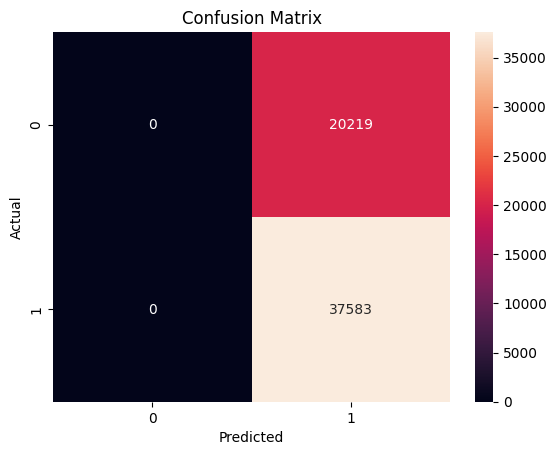

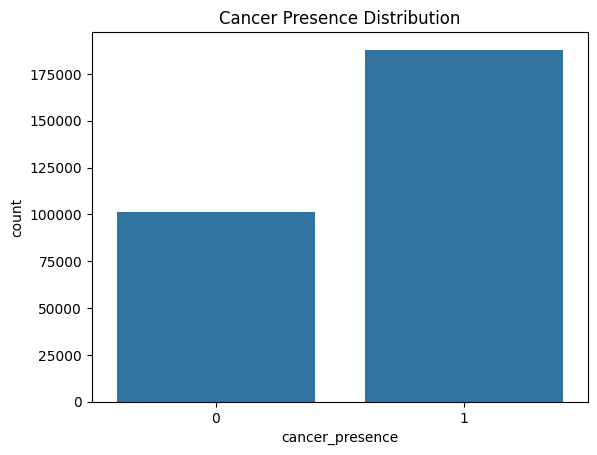

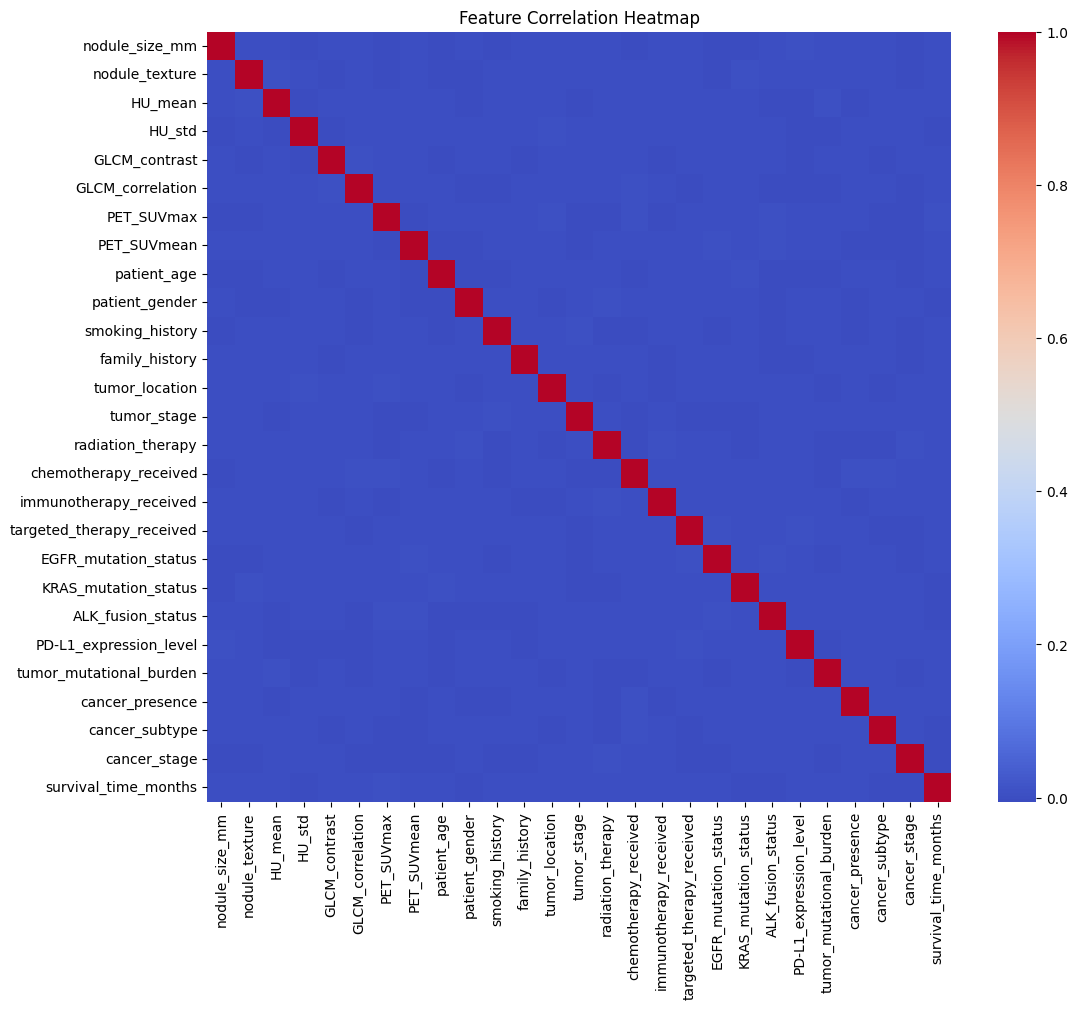

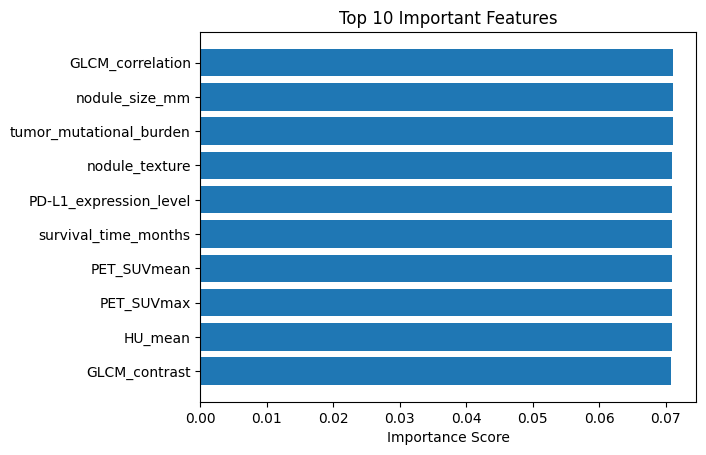

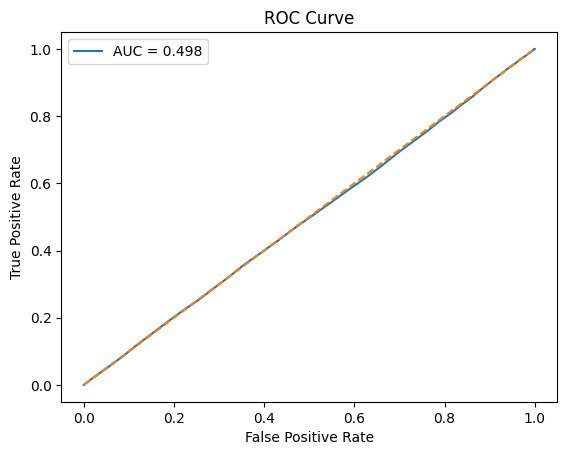


📊 ROC-AUC Score: 0.4979627286570855


In [ ]:
# =========================================
# 1. Import required libraries
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# =========================================
# 2. Load dataset (already uploaded in Colab)
# =========================================
df = pd.read_csv("LungCanC2024_Dataset.csv")

print("✅ Dataset Loaded")
print("Shape:", df.shape)
display(df.head())

# =========================================
# 3. Handle missing values
# =========================================
df = df.dropna()

# =========================================
# 4. Encode categorical columns
# =========================================
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

# =========================================
# 5. Define features & target
# =========================================
X = df.drop("cancer_presence", axis=1)
y = df["cancer_presence"]

# =========================================
# 6. Train-test split with stratification
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 7. Train Random Forest (class imbalance handled)
# =========================================
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

print("✅ Model Training Completed")

# =========================================
# 8. Predictions & Accuracy
# =========================================
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\n🎯 Accuracy:", accuracy)

print("\n📄 Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# =========================================
# 9. Confusion Matrix
# =========================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# 10. Target Class Distribution
# =========================================
plt.figure()
sns.countplot(x=y)
plt.title("Cancer Presence Distribution")
plt.show()

# =========================================
# 11. Correlation Heatmap
# =========================================
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# =========================================
# 12. Feature Importance (Top 10)
# =========================================
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

# =========================================
# 13. ROC Curve & AUC Score
# =========================================
y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("\n📊 ROC-AUC Score:", auc_score)
